# Stage 5: Hyperparameter Tuning with Purged CV

AFML Ch 9 + Ch 14. We sweep RF and XGBoost hyperparameters with `RandomizedSearch` over `PurgedKFold` (sample-weighted), log every trial, then deflate the best trial's Sharpe to test whether it survives multiple-testing correction.

In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sys.path.append('../')
from src.cross_validation import PurgedKFold
from src.hyperparameter_tuning import (
    purged_random_search,
    deflated_sharpe_ratio_for_trials,
)

plt.style.use('seaborn-v0_8-darkgrid')
RNG = 42

## 1. Load modelling dataset

In [2]:
dataset = pd.read_parquet('../data/processed/nvda_modelling_dataset.parquet')
X = dataset.drop(columns=['label', 'weight', 't1'])
y = dataset['label'].astype(int)         # -1 / +1 for RF
y_xgb = (y == 1).astype(int)             # 0 / 1 for XGBoost
sample_weight = dataset['weight']
t1 = dataset['t1']

print(f'X shape: {X.shape}')
print(f'baseline (always +1) accuracy: {(y == 1).mean():.4f}')

pkf = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)

X shape: (171, 17)
baseline (always +1) accuracy: 0.5673


## 2. Define hyperparameter distributions

We deliberately keep the search space modest (small dataset, 171 events).

In [3]:
rf_dist = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [3, 5, 7, 10],
    'min_samples_leaf':  [5, 10, 20, 30],
    'max_features':      ['sqrt', 0.5, 1.0],
    'class_weight':      ['balanced_subsample', None],
}

xgb_dist = {
    'n_estimators':     [100, 200, 500],
    'max_depth':        [2, 3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.5, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'gamma':            [0.0, 0.1, 0.5],
    'reg_lambda':       [0.1, 1.0, 10.0],
}

N_ITER = 25

## 3. Run randomised search (RF, then XGB)

In [4]:
rf_base = RandomForestClassifier(random_state=RNG, n_jobs=-1)
xgb_base = XGBClassifier(
    random_state=RNG, n_jobs=-1, eval_metric='logloss'
)

rf_search = purged_random_search(
    clf=rf_base, X=X, y=y, sample_weight=sample_weight,
    param_dist=rf_dist, cv=pkf, n_iter=N_ITER,
    scoring='accuracy', random_state=RNG,
)
print(f"RF  best: mean={rf_search['best_mean_score']:.4f} "
      f"std={rf_search['best_std_score']:.4f}")
print('  params:', rf_search['best_params'])

RF  best: mean=0.5612 std=0.0941
  params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 7, 'class_weight': 'balanced_subsample'}


In [5]:
xgb_search = purged_random_search(
    clf=xgb_base, X=X, y=y_xgb, sample_weight=sample_weight,
    param_dist=xgb_dist, cv=pkf, n_iter=N_ITER,
    scoring='accuracy', random_state=RNG,
)
print(f"XGB best: mean={xgb_search['best_mean_score']:.4f} "
      f"std={xgb_search['best_std_score']:.4f}")
print('  params:', xgb_search['best_params'])

XGB best: mean=0.5555 std=0.0871
  params: {'subsample': 0.5, 'reg_lambda': 0.1, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 0.7}


## 4. Trial logs

In [6]:
rf_log = rf_search['log'].assign(model='RF')
xgb_log = xgb_search['log'].assign(model='XGB')
tuning_log = pd.concat([rf_log, xgb_log], ignore_index=True)

print('RF trial summary:')
print(rf_log['mean_score'].describe().round(4))
print()
print('XGB trial summary:')
print(xgb_log['mean_score'].describe().round(4))

RF trial summary:
count    25.0000
mean      0.5322
std       0.0119
min       0.5141
25%       0.5259
50%       0.5318
75%       0.5376
max       0.5612
Name: mean_score, dtype: float64

XGB trial summary:
count    25.0000
mean      0.5163
std       0.0258
min       0.4612
25%       0.4965
50%       0.5259
75%       0.5318
max       0.5555
Name: mean_score, dtype: float64


## 5. Trial-score distribution (P14 input)

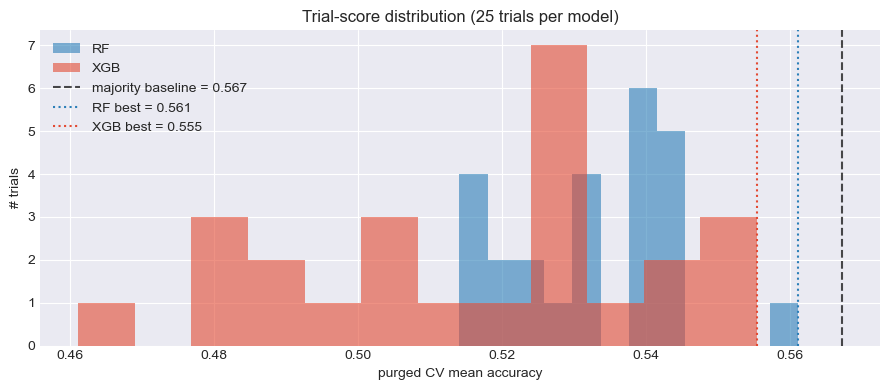

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rf_log['mean_score'], bins=12, alpha=0.6, label='RF', color='#2c7fb8')
ax.hist(xgb_log['mean_score'], bins=12, alpha=0.6, label='XGB', color='#e34a33')
ax.axvline((y == 1).mean(), color='k', linestyle='--', alpha=0.7,
           label=f'majority baseline = {(y == 1).mean():.3f}')
ax.axvline(rf_search['best_mean_score'],  color='#2c7fb8', linestyle=':',
           label=f"RF best = {rf_search['best_mean_score']:.3f}")
ax.axvline(xgb_search['best_mean_score'], color='#e34a33', linestyle=':',
           label=f"XGB best = {xgb_search['best_mean_score']:.3f}")
ax.set_xlabel('purged CV mean accuracy')
ax.set_ylabel('# trials')
ax.set_title(f'Trial-score distribution ({N_ITER} trials per model)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 2D hyperparameter heatmap

For each model we pick two key hyperparameters and average the trial score over all (param₁, param₂) bins.

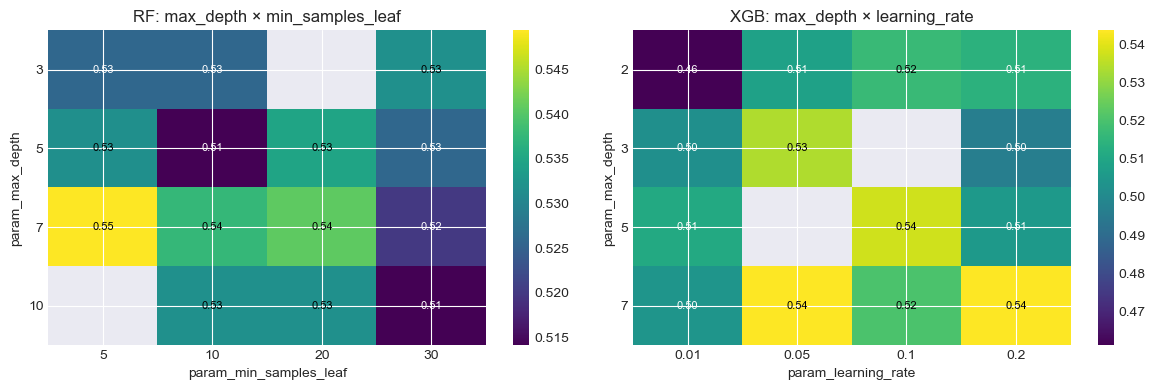

In [8]:
def heatmap_pivot(log_df, p1, p2):
    return log_df.pivot_table(
        index=p1, columns=p2, values='mean_score', aggfunc='mean'
    )

rf_pivot = heatmap_pivot(rf_log, 'param_max_depth', 'param_min_samples_leaf')
xgb_pivot = heatmap_pivot(xgb_log, 'param_max_depth', 'param_learning_rate')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, piv, title in [
    (axes[0], rf_pivot,  'RF: max_depth × min_samples_leaf'),
    (axes[1], xgb_pivot, 'XGB: max_depth × learning_rate'),
]:
    im = ax.imshow(piv.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel(piv.columns.name)
    ax.set_ylabel(piv.index.name)
    ax.set_title(title)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v < piv.values[~np.isnan(piv.values)].mean() else 'black',
                        fontsize=8)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7. Deflated Sharpe Ratio across trials

AFML Ch 14: the best trial's CV Sharpe is biased upward by selection across `N` trials. Deflate against the expected maximum SR under the null of zero true skill, then read DSR ∈ [0, 1] as the probability that the true SR exceeds that benchmark.

In [9]:
rf_fold_arrays  = [t['fold_scores'] for t in rf_search['trials']]
xgb_fold_arrays = [t['fold_scores'] for t in xgb_search['trials']]

rf_dsr  = deflated_sharpe_ratio_for_trials(rf_fold_arrays,
             best_idx=rf_search['best_idx'])
xgb_dsr = deflated_sharpe_ratio_for_trials(xgb_fold_arrays,
             best_idx=xgb_search['best_idx'])

dsr_table = pd.DataFrame([rf_dsr, xgb_dsr], index=['RF', 'XGB']).round(4)
dsr_table

,n_trials,best_sr,expected_max_sr,dsr,best_mean,best_std,best_skew,best_kurt
RF,25,5.9648,2.2055,0.9651,0.5612,0.0941,-0.8376,2.2585
XGB,25,6.3738,6.7686,0.4361,0.5555,0.0871,-0.9119,2.6980


## 8. Persist artefacts

In [10]:
best_params = {
    'rf':  {
        'params': rf_search['best_params'],
        'mean_score': rf_search['best_mean_score'],
        'std_score':  rf_search['best_std_score'],
        'dsr': rf_dsr,
    },
    'xgb': {
        'params': xgb_search['best_params'],
        'mean_score': xgb_search['best_mean_score'],
        'std_score':  xgb_search['best_std_score'],
        'dsr': xgb_dsr,
    },
    'meta': {
        'n_iter_per_model': N_ITER,
        'cv':                'PurgedKFold(n_splits=5, pct_embargo=0.01)',
        'scoring':           'accuracy',
        'baseline_majority': float((y == 1).mean()),
    },
}

os.makedirs('../models', exist_ok=True)
with open('../models/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=lambda o: int(o)
              if isinstance(o, np.integer) else float(o)
              if isinstance(o, np.floating) else str(o))

tuning_log_to_save = tuning_log.copy()
for col in tuning_log_to_save.select_dtypes(include='object').columns:
    tuning_log_to_save[col] = tuning_log_to_save[col].astype(str)
tuning_log_to_save.to_parquet('../data/processed/tuning_log.parquet')

print('Saved:')
print('  ../models/best_params.json')
print('  ../data/processed/tuning_log.parquet')
print()
print(json.dumps({k: v for k, v in best_params.items() if k != 'meta'},
                 indent=2, default=str)[:1200])

Saved:
  ../models/best_params.json
  ../data/processed/tuning_log.parquet

{
  "rf": {
    "params": {
      "n_estimators": 200,
      "min_samples_leaf": 5,
      "max_features": "sqrt",
      "max_depth": 7,
      "class_weight": "balanced_subsample"
    },
    "mean_score": 0.5611764705882353,
    "std_score": 0.09408087516952829,
    "dsr": {
      "n_trials": 25,
      "best_sr": 5.964830467159534,
      "expected_max_sr": 2.205546859550891,
      "dsr": 0.9651135251270005,
      "best_mean": 0.5611764705882353,
      "best_std": 0.09408087516952829,
      "best_skew": -0.837607086311853,
      "best_kurt": 2.2585375045618723
    }
  },
  "xgb": {
    "params": {
      "subsample": 0.5,
      "reg_lambda": 0.1,
      "n_estimators": 500,
      "max_depth": 7,
      "learning_rate": 0.2,
      "gamma": 0.5,
      "colsample_bytree": 0.7
    },
    "mean_score": 0.5554621848739496,
    "std_score": 0.08714816479383332,
    "dsr": {
      "n_trials": 25,
      "best_sr": 6.37376800

C:\Users\yamam\AppData\Local\Temp\ipykernel_24480\1628325512.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in tuning_log_to_save.select_dtypes(include='object').columns:


## 9. Notes

- `DSR` near or below 0.5 means the best trial is **indistinguishable from selection bias** given the trial count — i.e. the apparent edge could be explained by trying many configs. Values above ~0.95 suggest a robust improvement.
- The 5-fold CV gives only 5 score observations per trial, so the skew/kurtosis adjustments inside PSR are noisy. With more events (more CUSUM triggers, or longer-horizon dataset) these become tighter.
- Stage 6 (feature importance) will use the **best parameters** found here; Stage 7 (meta-labeling) will reuse the resulting RF as primary model.